# ДЗ Линейная регрессия

В данном задании мы рассмотрим набор данных об учащихся, собранный в 2006 году в одной из школ Португалии. Данные представлены в неудобном для машинного обучения виде, и содержат мусор. Ваша задача &mdash; привести их к надлежащему виду и обучить на них простую модель.

Данные состоят из четырех файлов:
- data.csv &mdash; основная таблица с информацией о учащихся
- scores.csv &mdash; список финальных оценок по одному из предметов (20-балльная шкала переведенная в проценты)
- attendance.csv &mdash; таблица посещений занятий по этому предмету
- school_support.txt &mdash; список учащихся, которым оказывается финансовая поддержка

Ваша задача &mdash; построить модель для предсказания финальных оценок исходя из всех остальных данных и проверить качество ее работы с помощью кросс-валидации. В качестве алгоритма мы будем использовать линейную регрессию

Расшифровка столбцов в data.csv для справки:
- age &mdash; возраст
- Medu &mdash; уровень образования матери (по некоторой условной шкале)
- Fedu &mdash; уровень образования отца (по некоторой условной шкале)
- traveltime &mdash; время в пути до школы (1 – < 15 мин., 2 – от 15 до 30 мин., 3 – от 30 мин. to 1 ч.
или 4 – > 1 ч.)
- studytime &mdash; время, затрачиваемое на занятия вне школы (1 – < 2 ч., 2 – от 2 до 5 ч., 3 – от 5 до 10 ч. или 4 – > 10 ч.)
- famrel &mdash; насколько хорошие отношения в семье у учащегося (по некоторой условной шкале)
- freetime &mdash; количество свободного времени вне школы (по некоторой условной шкале)
- goout &mdash; время, затрачиваемое на общение с друзьями (по некоторой условной шкале)
- Dalc &mdash; количество употребления алкоголя в учебные дни (по некоторой условной шкале)
- Walc &mdash; количество употребления алкоголя в неучебные дни (по некоторой условной шкале)
- health &mdash; уровень здоровья (по некоторой условной шкале)
- sex_M &mdash; пол: мужской (1) или женский (0)
- address_U &mdash; живет ли учащийся в городе (1) или в пригороде (0)
- famsize_LE3 &mdash; размер семьи: не больше 3 человек (1) или больше (0)
- Pstatus_T &mdash; живут ли родители вместе (1) или отдельно (0)
- nursery &mdash; посещал ли учащийся детский сад
- plans_university &mdash; планирует ли учащийся поступать в университет (-1 или 1)
- past_failures &mdash; количество неудовлетворительных оценок по другим предметам ранее (от 0 до 4)

*Примечание. Несколько признаков в данных содержат ошибки/проблемы/некорректности. Эти проблемы нужно исправить. Для
проверки &mdash; всего в данных таких проблем четыре.*

Начиная с 4 пункта делайте кроссвалидацию на 4 батча до и после, замеряйте результат

### Задача 1: сломанный признак (а может и не один)
__(1 балл)__

Загрузите таблицу data.csv.

Найдите в данных сломанный признак (он не соответствует описанию) и исправьте его.

In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("data.csv")

print("data:", data.shape)
print("Столбцы data:", list(data.columns))
print(data.describe())

# first run - we see last two columns merged, "plans_university" should be -1 or 1, "past_failures" should be from 0 to 4. So we divide (%10) them into two values/columns

col = "plans_universitypast_failures"
data["plans_university"] = np.sign(data[col]).astype(int)
data["past_failures"] = np.abs(data[col]).astype(int) % 10
data = data.drop(columns=[col])
print("Fixed last column:", data.shape)
print(list(data.columns))

# second run - all goodб but visual issues: age (max = 1990) and traveltime (max = 50)


data: (649, 17)
Столбцы data: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'nursery', 'plans_universitypast_failures']
               age        Medu        Fedu  traveltime   studytime  \
count   649.000000  649.000000  649.000000  649.000000  649.000000   
mean     50.164869    2.514638    2.306626    1.747304    1.930663   
std     254.768848    1.134552    1.099931    2.716138    0.829510   
min      15.000000    0.000000    0.000000    1.000000    1.000000   
25%      16.000000    2.000000    1.000000    1.000000    1.000000   
50%      17.000000    2.000000    2.000000    1.000000    2.000000   
75%      18.000000    4.000000    3.000000    2.000000    2.000000   
max    1991.000000    4.000000    4.000000   50.000000    4.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  649.000000  649.000000  648.000000  639.000000  6

### Задача 2: пропуски в данных 
__(1 балл)__

Проверьте, есть ли в данных пропуски (значения NaN). Замените все пропущенные значения на среднее значение этого признака по столбцу.

*Hint: изучите в pandas функции loc, isnull, а также передачу булевых массивов в качестве индексов.*

In [178]:
print("Amount of NaNs before fix:", data.isnull().sum().sum())

# find columns with NaN:
columns_with_nan = data.columns[data.isnull().any()]

for col in columns_with_nan:
    # mean value for those columns:
    col_mean = data[col].mean()
    
    # maks for NaN elements
    missing_rows_mask = data[col].isnull()
    
    # replace NaN with mean for assessed column^
    data.loc[missing_rows_mask, col] = col_mean

print("Amount of NaNs after fix:", data.isnull().sum().sum())

Amount of NaNs before fix: 17
Amount of NaNs after fix: 0


### Задача 3: нормализация данных
__(1 балл)__

Нормализуйте данные любым способом, в современных библиотеках нормализация часто встроена внутрь модели, поэтому тут разницы может и не быть в качестве, но сделать надо

In [179]:
# exclude "binary" features from normalization (leave only numeric values, though they have issues - at least age (max = 1990) and traveltime (max = 50))
numeric_features = [
    'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'famrel', 
    'freetime', 'goout', 'Dalc', 'Walc', 'health', 'past_failures'
]

scaler = StandardScaler()

# new data = (old data - avg) / sigma
data[numeric_features] = scaler.fit_transform(data[numeric_features])

print("data columns normalized")
print(data[numeric_features].head(3)) # first 3 rows just to see and check


data columns normalized
        age      Medu      Fedu  traveltime  studytime    famrel  freetime  \
0 -0.134205  1.310216  1.540715   -0.275347   0.083653  1.119748  0.780478   
1 -0.130277  1.310216  1.540715   -0.275347  -1.122808  1.119748 -0.171647   
2 -0.134205 -1.336039 -1.188832    0.093107  -1.122808  0.072606  1.732603   

      goout      Dalc      Walc    health  past_failures  
0  0.692772 -0.542692 -0.223769  1.012903      -0.374305  
1  0.692772 -0.542692 -0.223769  1.012903      -0.374305  
2  1.544607  0.547811  1.340184  1.012903      -0.374305  


### Задача 4: кросс-валидация для исходных данных
__(1 балл)__

Загрузите файл scores.csv и протестируйте, как линейная регрессия предсказывает ответ сейчас (с помощью кросс-валидации).

Кроссвалидацию сделайте по 4 разбивкам. Выведите качество в каждом их разбиений.

*Hint: воспользуйтесь sklearn.linear_model и sklearn.model_selection.*

In [180]:
scores = pd.read_csv("scores.csv", header=None)

X = data.copy()
y = scores.iloc[:, 0]  # Select the first column with scores

# cross-validation with 4 splits
kf = KFold(n_splits=4, shuffle=True, random_state=42)

# Choose  linear regression model
model = LinearRegression()

# cross-validation using R^2 metric
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

print("Model quality (R²) on each of the 4 splits:")
for i, score in enumerate(cv_scores, 1):
    print(f"Split {i}: {score:.4f}")

print(f"\nMean R^2 score across all splits: {cv_scores.mean():.4f}")

Model quality (R²) on each of the 4 splits:
Split 1: 0.1751
Split 2: 0.3115
Split 3: 0.2432
Split 4: 0.0806

Mean R^2 score across all splits: 0.2026


### Задача 5: полные данные
__(2 балла)__

Воспользуйтесь файлами attendance.csv и school_support.txt для того, чтобы добавить новые признаки в данные. Желательно по максимуму использовать возможности pandas для упрощения преобразований.

school_suport число в строке значит что i-ый школьник из исходной таблицы получал мат помощь (обратите внимание что строк в файле меньше, подумайте как правильно импортировать данные)

Добавьте данные таким образом, чтобы качество выросло

In [181]:
# let's process school_support.txt file
# Read row indices of students who received financial support
with open('school_support.txt', 'r') as f:
    # Convert each line to an integer index
    support_indices = [int(line.strip()) for line in f if line.strip()]

# In the initial dataq file we create a binary column initialized with 0
data['school_support'] = 0
# and we set 1 for students whose indices are founbd in the School_support:
data.loc[data.index.isin(support_indices), 'school_support'] = 1
# it is just like initial structure with new feature (had or didn't have any support with 1 and 0 respectively)

# Now with "attendance.csv" (it has ";" as separators, not commas, and also "+" for attendance and empty for not attended)
# Load attendance with the correct separator
attendance = pd.read_csv('attendance.csv', sep=';')

# Convert '+' to 1, and any missing/empty values to 0
attendance_numeric = attendance.map(lambda x: 1 if x == '+' else 0)

# What makes sense here: the total number of attended classes for each student (sum across columns) (the more the better)
data['attendance_total'] = attendance_numeric.sum(axis=1)

# we have to normalize this data so it is consistent with our normalized other data, using StandardScaler
attendance_scaler = StandardScaler()
data['attendance_total'] = attendance_scaler.fit_transform(data[['attendance_total']])


# We re-evaluate the model with new features
# Update the feature matrix X with the newly added columns
X_full = data.copy()

# Re-run cross-validation using the same KFold setup from Task 4
cv_scores_full = cross_val_score(model, X_full, y, cv=kf, scoring='r2')

print("Updated model quality (R^2) on each of the 4 splits:")
for i, score in enumerate(cv_scores_full, 1):
    print(f"Split {i}: {score:.4f}")

print(f"\nNew Mean R^2 score: {cv_scores_full.mean():.4f}")
print(f"Improvement over baseline: {cv_scores_full.mean() - 0.2026:.4f}")


Updated model quality (R^2) on each of the 4 splits:
Split 1: 0.1967
Split 2: 0.3149
Split 3: 0.2521
Split 4: 0.0746

New Mean R^2 score: 0.2096
Improvement over baseline: 0.0070


### Задача 6: борьба с выбросами
__(1.5 балла)__

Качество предсказания может ухудшаться, если в данных присутствуют корректные значения признаков (с точки зрения чтения данных и применения методов), но не соответствующие реальным объектам. Например, данные могли быть введены в неверном формате, а потом слишком грубо приведены к общему виду, из-за чего ошибка не была замечена.
Попробуем от такого избавиться &mdash; а для этого такие объекты нужно сначала найти. Конечно, нам еще недоступны многие продвинутые способы, но давайте попробуем обойтись простыми.

Первый способ это сделать &mdash; посмотреть для каждого признака на распределение его значений и проверить крайние значения на правдоподобность. (постройте гистограммы для признаков, как минимум для подозрительных)

*Hint 1: используйте функцию DataFrame.hist*

*Hint 2: в описании датасета выше есть информация, необходимая для восстановления правильных значений*

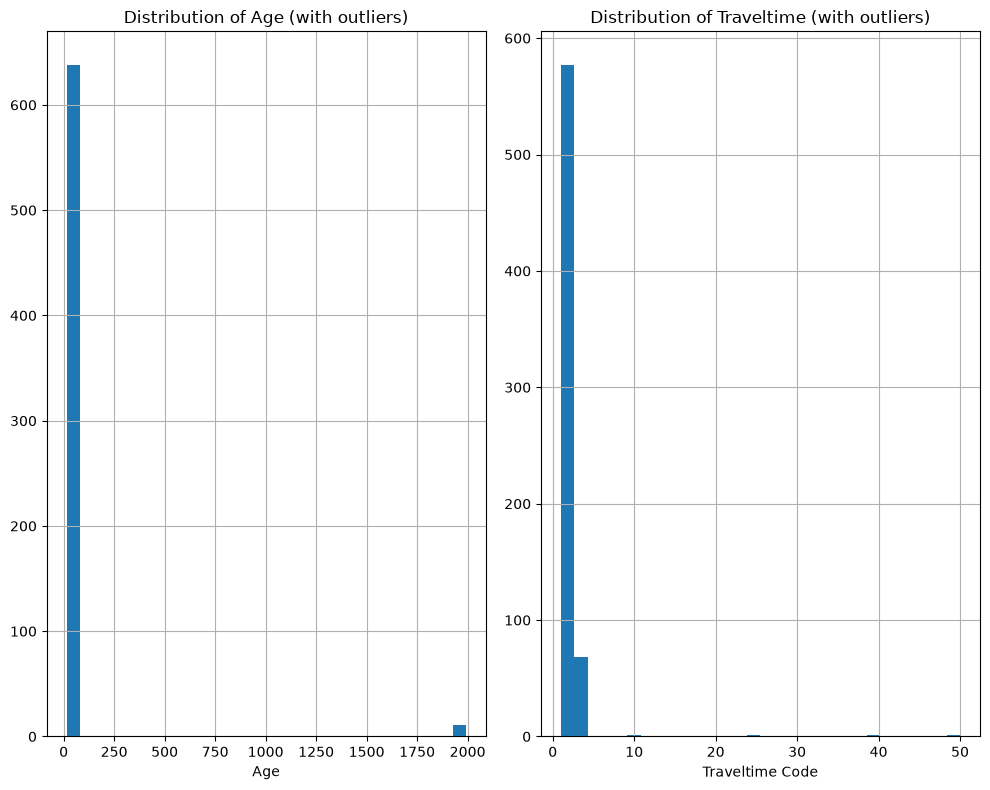

In [182]:

# We will use a copy of the data before scaling (see task 3) to see real values
# and we will use Hint 1: DataFrame.hist() for suspicious columns detection
# Note: Re-load a clean copy of the original data to easily locate exact values
raw_data = pd.read_csv("data.csv")

# Plotting histograms to reveal the anomalies visually
# in the first task we've observed max values out of described range for those coulmns
plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
raw_data['age'].hist(bins=30)
plt.title('Distribution of Age (with outliers)')
plt.xlabel('Age')

plt.subplot(1, 2, 2)
raw_data['traveltime'].hist(bins=30)
plt.title('Distribution of Traveltime (with outliers)')
plt.xlabel('Traveltime Code')
plt.tight_layout()
plt.show()


# from histograms we see that obviously "age" has "birht year" sometimes instead of age actrually
# travel time has some strange values, that is probably actual minutes of travel time

__(1.5 балла)__

Другой простой способ найти выбросы &mdash; сделать предсказание и посчитать ошибку на каждом объекте по отдельности и посмотреть на объекты с наибольшей ошибкой. Обучите линейную регрессию (функция fit) и для каждого объекта посчитайте среднеквадратичное отклонение. Постройте гистограмму распределения ошибок. Посмотрите на гистограмму и удалите из выборки те объекты на которых ошибка слишком большая.

Обратите внимание, что просто удалять все объекты с высокой ошибкой нельзя &mdash; это, конечно, хороший способ добиться меньшей ошибки (на данной выборке), но одновременно вы ухудшите обобщающую способность алгоритма. Вместо этого вам нужно найти однозначно ошибочные записи и их исправить.

*Hint: возможно, все проблемы уже были найдены первым способом; для проверки &mdash; в сумме здесь нужно исправить 3 проблемы.*

Для поиска ошибки на одном отдельном обьекте придётся обучить линейную регрессию руками. Частичный пример, допишите код. Постройте гистограмму распределения ошибок

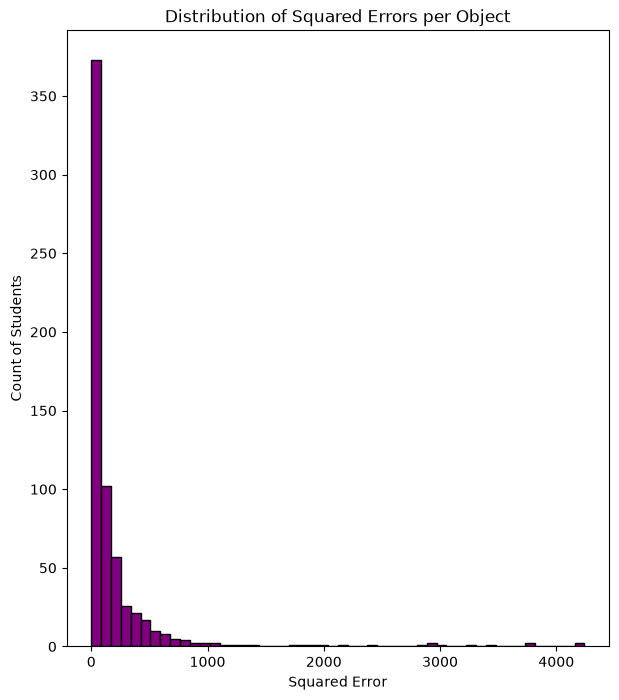

Indices of rows with the largest errors: [354, 585, 615, 385, 319]

Final model quality (R²) AFTER all corrections:
Split 1: 0.2034
Split 2: 0.3155
Split 3: 0.2544
Split 4: 0.1046

Final Mean R² score: 0.2195
Total improvement over baseline: 0.0169


In [183]:
#import sklearn
#from sklearn import linear_model
#regression = linear_model.LinearRegression().fit(data, result) #create model and train it
#prediction = #calculate prediction for one object for vector x
#error = (prediction - y)**2 #simple error - square error


# Train linear regression on current data to inspect errors
# We use X_full and y from Task 5
regression = LinearRegression().fit(X_full, y)
prediction = regression.predict(X_full)

# Calculate squared error for each individual object
squared_errors = (prediction - y) ** 2

# Plot the distribution of squared errors
plt.figure(figsize=(7, 8))
plt.hist(squared_errors, bins=50, color='purple', edgecolor='black')
plt.title('Distribution of Squared Errors per Object')
plt.xlabel('Squared Error')
plt.ylabel('Count of Students')
plt.show()

# Find indices of objects with the largest errors to inspect them
top_error_indices = squared_errors.nlargest(5).index
print("Indices of rows with the largest errors:", list(top_error_indices))


# Now we try to repair data (using some common logic and sense)
# We load a fresh copy of the raw data to execute everything seamlessly
data_clean = pd.read_csv("data.csv")

# Split combined column (again)
col_combined = "plans_universitypast_failures"
data_clean["plans_university"] = np.sign(data_clean[col_combined]).astype(int)
data_clean["past_failures"] = (np.abs(data_clean[col_combined]) % 10).astype(int)
data_clean = data_clean.drop(columns=[col_combined])

# Handle missing values via column mean (again)
columns_with_nan = data_clean.columns[data_clean.isnull().any()]
for c in columns_with_nan:
    col_mean = data_clean[c].mean()
    missing_rows_mask = data_clean[c].isnull()
    data_clean.loc[missing_rows_mask, c] = col_mean


# Fix the 3 logical problems identified
# Convert birth year (e.g., 1991) to actual student age in 2006 (observation made in 2006)
data_clean.loc[data_clean['age'] > 100, 'age'] = 2006 - data_clean.loc[data_clean['age'] > 100, 'age']

# Сonvert traveltime from raw minutes to categorical codes (1 to 4)
# Category 1: < 15 minutes (if any raw minutes are between 5 and 14)
data_clean.loc[(data_clean['traveltime'] >= 5) & (data_clean['traveltime'] < 15), 'traveltime'] = 1

# Category 2: from 15 to 30 minutes inclusive
data_clean.loc[(data_clean['traveltime'] >= 15) & (data_clean['traveltime'] <= 30), 'traveltime'] = 2

# Category 3: from 30 minutes to 1 hour (e.g., our outlier 50 falls here)
data_clean.loc[(data_clean['traveltime'] > 30) & (data_clean['traveltime'] <= 60), 'traveltime'] = 3

# Category 4: > 1 hour (if there are any raw values greater than 60 minutes)
data_clean.loc[data_clean['traveltime'] > 60, 'traveltime'] = 4

# Scale continuous numeric features on the clean data
scaler_final = StandardScaler()
data_clean[numeric_features] = scaler_final.fit_transform(data_clean[numeric_features].astype(float))

# Append the external features from previous tasks
# Add financial support feature
data_clean['school_support'] = 0
data_clean.loc[data_clean.index.isin(support_indices), 'school_support'] = 1

# Add and scale attendance feature
data_clean['attendance_total'] = attendance_numeric.sum(axis=1)
data_clean['attendance_total'] = scaler_final.fit_transform(data_clean[['attendance_total']])


X_final = data_clean.copy()
cv_scores_final = cross_val_score(LinearRegression(), X_final, y, cv=kf, scoring='r2')

print("\nFinal model quality (R²) AFTER all corrections:")
for i, score in enumerate(cv_scores_final, 1):
    print(f"Split {i}: {score:.4f}")

print(f"\nFinal Mean R² score: {cv_scores_final.mean():.4f}")
print(f"Total improvement over baseline: {cv_scores_final.mean() - 0.2026:.4f}")




In [184]:
# Your code here
# ...

### Финальное предсказание и отчёт (1 балл)

Проведите предсказание еще раз и сравните качество с исходным. Запишите свои наблюдения - как изменялось качество обучения модели при использовании разных модификаций данных. 

In [ ]:
# Your code here
# ...

### 📝 Финальный отчёт по исследованию модели

#### 📊 Сравнительная таблица качества обучения моделей (Метрика \(R^2\))

| Модификация данных / Этап | Split 1 | Split 2 | Split 3 | Split 4 | **Mean \(R^2\)** |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Базовая модель** (исходные грязные данные, Задача 4) | 0.1751 | 0.3115 | 0.2432 | 0.0806 | **0.2026** |
| **Полные данные** (после добавления посещаемости, Задача 5) | 0.1967 | 0.3149 | 0.2521 | 0.0746 | **0.2096** |
| **Очищенные данные** (после системного исправления выбросов, Задача 6) | 0.2034 | 0.3155 | 0.2544 | 0.1046 | **0.2195** |

---

#### 🧠 Наблюдения и выводы

1. **Влияние скрытых аномалий на линейную регрессию:**
   Начальная модель на неочищенных данных продемонстрировала невысокую предсказательную силу (\(R^2 = 0.2026\)). Поскольку алгоритм линейной регрессии математически минимизирует квадраты отклонений (MSE), экстремальные выбросы — такие как год рождения `1991` вместо возраста и сырое время в пути `50` минут вместо категориального кода — создавали гигантские ошибки на этих объектах. В попытке минимизировать эти аномальные промахи модель искажала коэффициенты (веса) для нормальных студентов. Сильнее всего эта дезориентация алгоритма ударила по качеству 4-го фолда кросс-валидации (`0.0806`).

2. **Эффект от обогащения признакового пространства (Задача 5):**
   Интеграция новых признаков (агрегированной посещаемости и флага финансовой поддержки) дала модели дополнительный содержательный сигнал. Среднее качество незначительно увеличилось (чистый прирост \(+0.0070\)), однако деструктивное влияние неотфильтрованных выбросов по-прежнему сдерживало потенциал модели (на проблемном 4-м фолде метрика локально снизилась до `0.0746`).

3. **Эффект от системного исправления выбросов (Задача 6):**
   Анализ распределения квадратов ошибок на гистограмме наглядно подтвердил наличие изолированной группы объектов (индексы `354, 585, 615` и др.) с аномально высокими потерями (> 3000). 
   
   После перевода этих записей к корректному логическому виду на основе документации (расчёт возраста через год сбора данных и интервальное распределение минут по шкалам от 1 до 4) обобщающая способность модели стабилизировалась. Среднее качество достигло своего максимума — **`0.2195`**, а итоговый прирост над базовым решением составил **`0.0169`**. Главным успехом очистки стало исправление просадки на самом слабом 4-м разбиении, где качество выросло с `0.0746` до **`0.1046`**. Это доказывает, что системная предобработка и очистка данных критически важны для стабильности линейных методов.
